In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['xtick.labelsize'] = 22
mpl.rcParams['ytick.labelsize'] = 22
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.fontsize'] = 22
mpl.rcParams['legend.frameon'] = False
#mpl.rcParams["markers.fillstyle"] = 'none'
mpl.rcParams["axes.labelpad"] = -0.5

In [2]:
data = np.load('traj.npy')[:,:2]
feature_number = data.shape[1]

In [3]:
labels = np.load('labels12417.npy')

In [4]:
start = np.where((labels[:-1]>-1) * (labels[1:]==-1))[0]+1
end = np.where((labels[:-1]==-1) * (labels[1:]>-1))[0]+1
assert len(start) == len(end)

In [5]:
npz_file = np.load('P_result.npz')
Px = npz_file['Px']
Pxcy = npz_file['Pxcy']
Pxcy_log = Pxcy

# estimate PXY

In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import sys
sys.path.append('/home/chinfo/JupyterProjects/DIKI2/')

import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from sklearn.decomposition import PCA
# gpu = tf.config.list_physical_devices('GPU')
# tf.config.experimental.set_memory_growth(gpu[0], True)

from flow import RealNVP
from training import training_loop
from estimating import inference_realnvp as inference
from calcp import cal_pxy

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter,find_peaks,peak_widths

In [7]:
mean_structure_list = []
for i in np.arange(labels.max()+1):
#     Px_label = Px[labels==i]
#     P_hist = np.histogram(Px_label,bins=200)
#     idx = np.where((Px_label>P_hist[1][P_hist[0].argmax()])*(Px_label<P_hist[1][P_hist[0].argmax()+1]))
    mean_structure_list.append(data[labels==i].mean(axis=0,keepdims=True).copy())
mean_structure = np.vstack(mean_structure_list)

In [8]:
possible_trans_idx = np.where(labels==-1)[0]
discontinuous_pos = np.where(possible_trans_idx[1:] != possible_trans_idx[:-1]+1)[0]+1
discontinuous_pos = np.insert(discontinuous_pos,0,0)
discontinuous_pos = np.insert(discontinuous_pos,len(discontinuous_pos),len(possible_trans_idx))

start_pt = possible_trans_idx[discontinuous_pos[:-1]]
end_pt = possible_trans_idx[discontinuous_pos[1:]-1] + 1
assert (labels[start_pt]==-1).all() * (labels[start_pt-1] !=-1).all() * (labels[end_pt] !=-1).all() * (labels[end_pt-1] ==-1).all()
assert len(start_pt) == len(end_pt)
assert (start_pt < end_pt).all()

In [9]:
from_state = np.zeros(len(possible_trans_idx),dtype='int64')-1
to_state = np.zeros(len(possible_trans_idx),dtype='int64')-1

from_state[(possible_trans_idx[...,None] == start_pt[None,...]).any(1)] = labels[start_pt-1]
for n,i in enumerate(from_state) :
    if i != -1:
        _from_state = i
    elif i == -1:
        from_state[n] = _from_state
        
to_state[(possible_trans_idx[...,None] == (end_pt[None,...]-1)).any(1)] = labels[end_pt]
to_state = to_state[::-1]
for n,i in enumerate(to_state) :
    if i != -1:
        _to_state = i
    elif i == -1:
        to_state[n] = _to_state
to_state = to_state[::-1]
assert (from_state!=to_state).all()

In [10]:
x_from_state = mean_structure[from_state]
x_possible_trans = data[possible_trans_idx]
x_to_state = mean_structure[to_state]

In [11]:
real_nvp = RealNVP(4,8,0,12)
_ = real_nvp(np.zeros((32,feature_number*2)))
real_nvp.load_weights('pxy_flow_lagtime1.h5')

In [12]:
gauss_trans,log_Jacobian,d2p_dx2,Pxy1 = \
inference(real_nvp,np.hstack((x_from_state*1+0*x_possible_trans,x_possible_trans)),batch_size=200000)

gauss_trans,log_Jacobian,d2p_dx2,Pxy2 = \
inference(real_nvp,np.hstack((x_possible_trans,x_from_state*1+0*x_possible_trans)),batch_size=200000)

gauss_trans,log_Jacobian,d2p_dx2,Pxy3 = \
inference(real_nvp,np.hstack((x_to_state*1+0*x_possible_trans,x_possible_trans)),batch_size=200000)

gauss_trans,log_Jacobian,d2p_dx2,Pxy4 = \
inference(real_nvp,np.hstack((x_possible_trans,x_to_state*1+0*x_possible_trans)),batch_size=200000)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]


In [13]:
Pxy_from_state = Pxy1+Pxy2
Pxy_to_state = Pxy3+Pxy4
trans_prob_double_side = np.abs(Pxy_from_state - Pxy_to_state)

In [14]:
state0 = 0
state1 = 1
condition0 = (from_state==state0)*(to_state==state1)+(from_state==state1)*(to_state==state0)
possible_trans_idx_conditioned = possible_trans_idx[condition0]
Pxy_from_state_conditioned = Pxy_from_state[condition0]
Pxy_to_state_conditioned = Pxy_to_state[condition0]


condition1 = (labels[start_pt-1]==state0)*(labels[end_pt]==state1)+(labels[start_pt-1]==state1)*(labels[end_pt]==state0)
length = (end_pt - start_pt)[condition1]

select_idx = []
top_n = 1
least_length = 5

init_pos = 0
for i,j in enumerate(length):
    _length = j
    _possible_trans_idx_conditioned = possible_trans_idx_conditioned[init_pos:(init_pos+_length)]
    _Pxy_from_state_conditioned = Pxy_from_state_conditioned[init_pos:(init_pos+_length)]
    _Pxy_to_state_conditioned = Pxy_to_state_conditioned[init_pos:(init_pos+_length)]
    _trans_prob_double_side = np.abs(_Pxy_from_state_conditioned - _Pxy_to_state_conditioned)
    
    idx = np.argsort(_trans_prob_double_side)[:top_n]
    if _length>least_length:
        select_idx.append(_possible_trans_idx_conditioned[idx].copy())
    
    init_pos += _length
    
select_idx = np.hstack(select_idx)
from scipy.signal import savgol_filter
svg_px = savgol_filter(-Px,50,7,0)
new_list_ts = select_idx[svg_px[select_idx].argsort()[:10]]

In [15]:
from scipy.signal import savgol_filter
svg_px = savgol_filter(-Px,50,7,0)
# svg_pxcy = np.abs(Pycx_log[1:] - Pxcy[:-1])

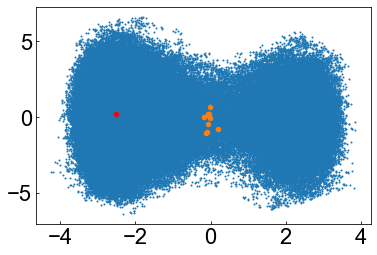

In [31]:
# start_idx = np.where((end - start) > ((end - start).mean() - 2*(end - start).std()))[0]
# list_ts = []
# for i in start_idx:
#     idx = np.arange(start[i],end[i])
#     idx_Px = -svg_pxcy[idx]
#     list_ts.append(idx[idx_Px.argmin()].copy())
# list_ts = np.array(list_ts)
# # new_list_ts = list_ts[-svg_pxcy[list_ts]>(-svg_pxcy[list_ts].mean()+0.5*svg_pxcy[list_ts].std())]
# try:
#     new_list_ts = list_ts[svg_pxcy[list_ts].argsort()[:30]]
# except:
#     new_list_ts = list_ts[svg_pxcy[list_ts].argsort()]
    
plt.figure()
plt.scatter(data[:,0],data[:,1],s=1)
plt.scatter(data[new_list_ts,0],data[new_list_ts,1],s=20,marker='o')
plt.scatter(data[1618:1619,0],data[1618:1619,1],s=20,marker='o',c='r')

In [28]:
-8.314*300/1000*(Px[labels==0].max()-Px[new_list_ts].mean())

-12.031635757684706

In [17]:
x = np.linspace(-4,4,401)[None,...]
y = np.linspace(-7,7,401)[...,None]
potential = 1./4. * x**4 - 3 * x**2 + x + 0.5 * y**2

Text(1.15, 1.06, 'Energy (kJ/mol)')

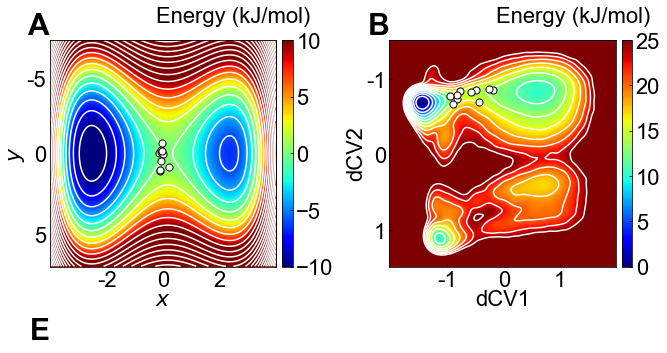

In [79]:
new_list_ts = select_idx[svg_px[select_idx].argsort()[:10]]
x_idx = np.digitize(data[new_list_ts,0], x[0])
y_idx = 401 - np.digitize(data[new_list_ts,1], y[:,0])

fig, ax = plt.subplots(figsize=[14/1.2, 5/1.2])
plt.imshow(potential,cmap='jet')
cbar = plt.colorbar(aspect=22,anchor=(-0.25,0.5))
cbar.set_ticks([-10,-5,0,5,10])
plt.text(0,1.0,'A', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=30,fontweight='bold')
plt.text(0,-0.35,'E', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=30,fontweight='bold')
plt.text(1.15,1.06,'Energy (kJ/mol)', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=22)
plt.clim([-10,10])
plt.contour(potential,levels=30,colors='white',linestyles='solid',alpha=1)
plt.xticks([100,200,300],[-2, 0, 2])
plt.yticks([67,200,343],[-5, 0, 5])
plt.xlabel('${x}$')
plt.ylabel('${y}$')
plt.scatter(x_idx,y_idx,s=50,facecolor='white',edgecolor='k', zorder=2.5,lw=1)

# ax = plt.subplot(spec[0,2])
# _data = np.load('../NTL9/transition_state_plot_data.npz')
# Heatmap = _data['Heatmap']*4.18
# x_idx = _data['x_idx']
# y_idx = _data['y_idx']
# plt.imshow(Heatmap.T[::-1],cmap='jet')
# cbar = plt.colorbar(aspect=22,anchor=(-0.25,0.5))
# plt.clim([0,25])

# for_contour = Heatmap.copy()
# # for_contour[for_contour>7*4.18] = np.inf
# plt.contour(for_contour.T[::-1],levels=np.linspace(0,6.*4.18,12),colors='white',linestyles='solid',alpha=1,zorder=2)
# plt.scatter(x_idx,y_idx,s=50,facecolor='white',edgecolor='k',zorder=3,lw=1)
# plt.xticks([51,101,151],[-1, 0, 1])
# plt.yticks([34,101,168],[-1, 0, 1])
# plt.xlabel('dCV1')
# plt.ylabel('dCV2')
# plt.text(0,1.0,'C', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=30,fontweight='bold')
# plt.text(0,-0.35,'F', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=30,fontweight='bold')
# plt.text(1.15,1.06,'Energy (kJ/mol)', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=22)


# ax = plt.subplot(spec[0,3])
# _data = np.load('../proteinG/transition_state_plot_data.npz')
# Heatmap = _data['Heatmap']*4.18
# x_idx = _data['x_idx']
# y_idx = _data['y_idx']
# plt.imshow(Heatmap.T[::-1],cmap='jet')
# cbar = plt.colorbar(aspect=22,anchor=(-0.25,0.5))
# plt.clim([0,25])

# for_contour = Heatmap.copy()
# # for_contour[for_contour>6*4.18] = np.inf
# plt.contour(for_contour.T[::-1],levels=np.linspace(0,6.0*4.18,10),colors='white',linestyles='solid',alpha=1,algorithm='mpl2014',negative_linestyles='solid')
# plt.scatter(x_idx,y_idx,s=50,facecolor='white',edgecolor='k',zorder=3,lw=1)
# plt.xticks([51,101,151],[-1, 0, 1])
# plt.yticks([34,101,168],[-1, 0, 1])
# plt.xlabel('dCV1')
# plt.ylabel('dCV2')
# plt.text(0,1.0,'D', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=30,fontweight='bold')
# plt.text(0,-0.35,'G', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=30,fontweight='bold')
# plt.text(1.15,1.06,'Energy (kJ/mol)', horizontalalignment='right', verticalalignment='bottom', transform=ax.transAxes,fontsize=22)
# # plt.savefig('transition_state_dpi300.png',dpi=300,bbox_inches='tight',pad_inches=0.01)

In [80]:
x_idx

array([91, 59, 79, 62, 76, 59, 56, 53, 88, 72])

In [ ]:
y